In [220]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

# Load the dataset
data = pd.read_csv("googleplaystore.csv")
data = data.head(10000)

# EDA

In [221]:
data.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [222]:
data.describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10000,10000,8738.000000,10000,10000,10000,9999,10000,10000,10000,10000,9993,9998
unique,8843,33,NaN,5732,429,21,2,90,6,117,1314,2677,32
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1810,NaN,518,1645,1504,9253,9254,8037,759,321,1419,2245
mean,NaN,NaN,4.198363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.507935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [223]:
print(f"The names of columns in this dataset are as follows:\n {data.columns}")

The names of columns in this dataset are as follows:
 Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')


In [224]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10000 non-null  object 
 1   Category        10000 non-null  object 
 2   Rating          8738 non-null   float64
 3   Reviews         10000 non-null  object 
 4   Size            10000 non-null  object 
 5   Installs        10000 non-null  object 
 6   Type            9999 non-null   object 
 7   Price           10000 non-null  object 
 8   Content Rating  10000 non-null  object 
 9   Genres          10000 non-null  object 
 10  Last Updated    10000 non-null  object 
 11  Current Ver     9993 non-null   object 
 12  Android Ver     9998 non-null   object 
dtypes: float64(1), object(12)
memory usage: 1015.8+ KB


In [225]:
data.describe()

,Rating
count,8738.000000
mean,4.198363
std,0.507935
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,5.000000


In [226]:
# Handle installs
data['Installs'] = data['Installs'].apply(lambda x : str(x).replace(',',''))
data['Installs'] = data['Installs'].apply(lambda x : str(x).replace('+',''))
data['Installs'] = data['Installs'].apply(lambda x : float(x))

# Visualizations

### How Many Apps For Each Category ?

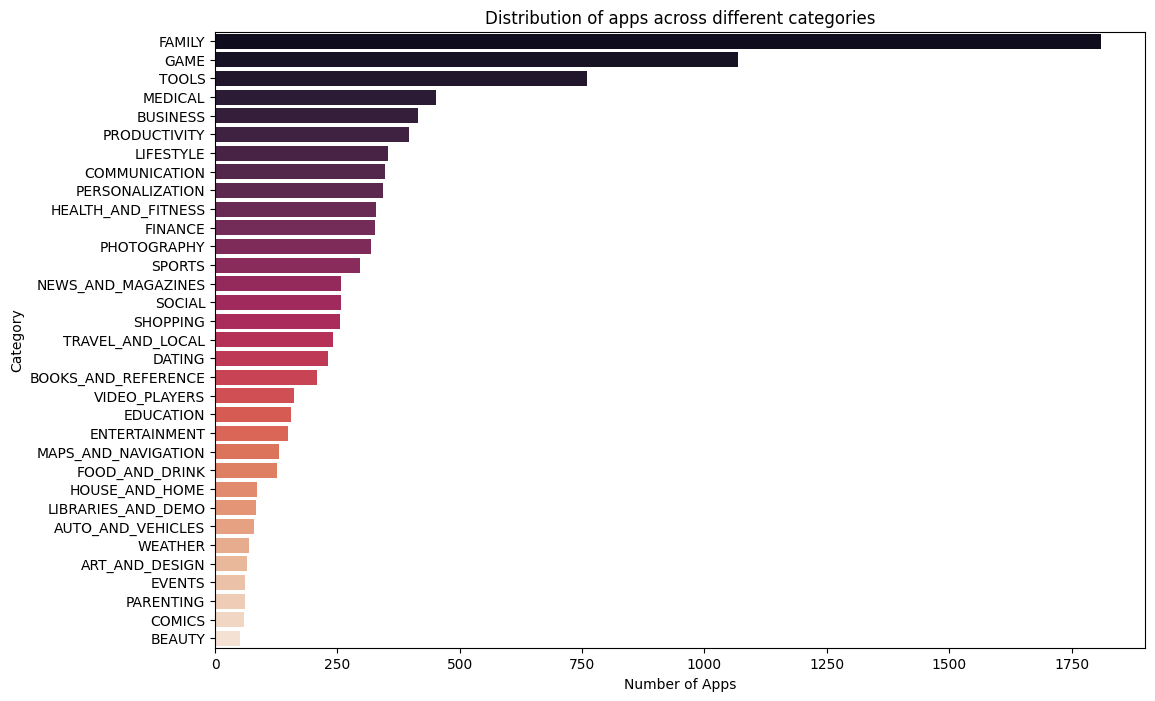

In [227]:
plt.figure(figsize=(12,8))
category = data['Category'].value_counts().index
#category
sns.countplot(data = data, y='Category', order = category, palette='rocket')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.title('Distribution of apps across different categories')
plt.show()

### Which Category Getting The Highest Average Rating?

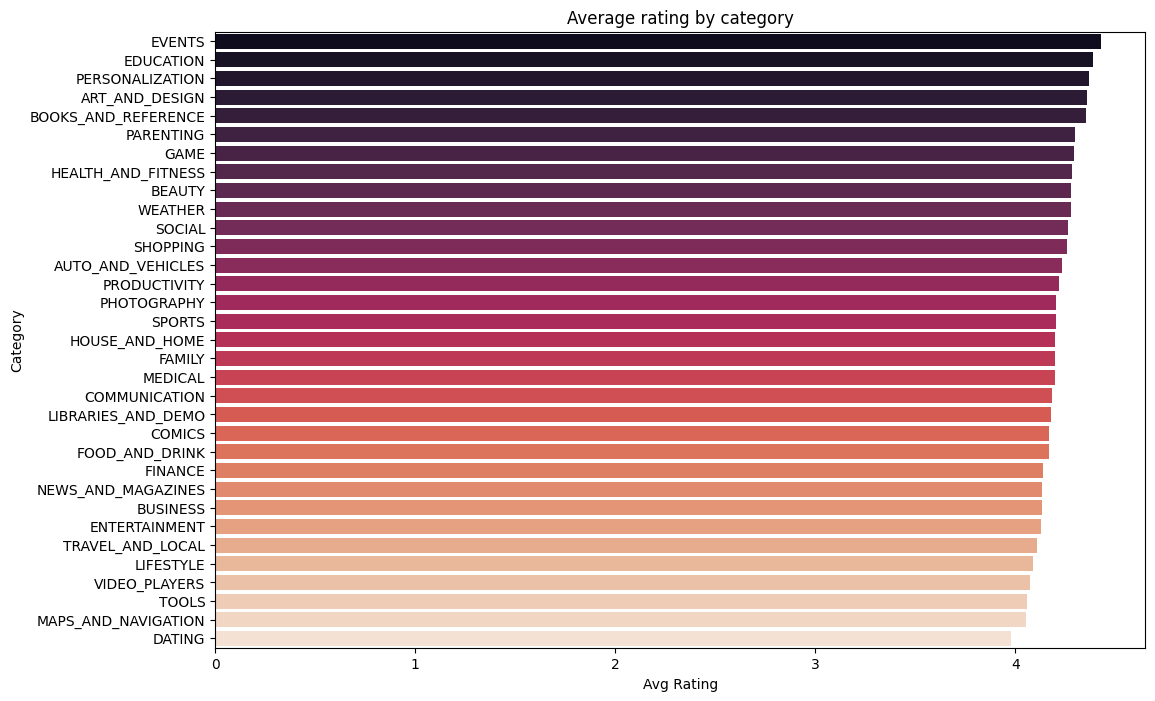

In [228]:
avg_cat_mean = data.groupby('Category')['Rating'].mean().sort_values(ascending = False)
#avg_cat_mean
plt.figure(figsize=(12,8))
sns.barplot(x = avg_cat_mean.values, y = avg_cat_mean.index, palette="rocket")
plt.xlabel('Avg Rating')
plt.ylabel('Category')
plt.title('Average rating by category')
plt.show()


### Total Number of Free and Paid Apps

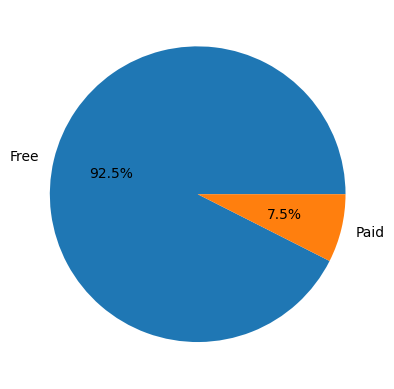

In [229]:
total = data['Type'].value_counts()
plt.pie(total,labels = ['Free','Paid'], autopct= "%1.1f%%")
plt.show()

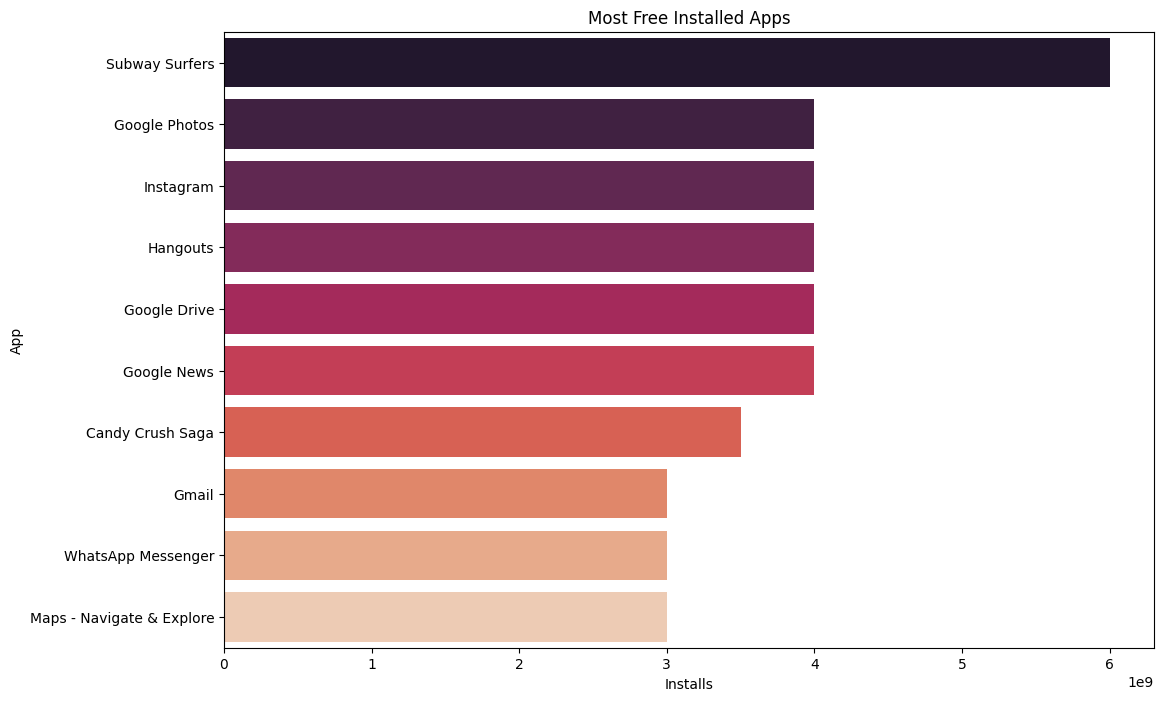

In [230]:
top_10_free_apps = data[data['Type'] == 'Free'].groupby('App')['Installs'].sum().sort_values(ascending = False).head(10)
plt.figure(figsize=(12,8))
sns.barplot(x = top_10_free_apps.values, y = top_10_free_apps.index, palette="rocket")
plt.xlabel('Installs')
plt.ylabel('App')
plt.title('Most Free Installed Apps')
plt.show()

# An interactive visualization
### You can hove over the average graph that will show you each and every rating you can observer the rating changes for each pixel

In [231]:
fig = px.bar(data_frame=data, x='Category', y='Rating', title='Average Ratings by Category')

fig.update_layout(
    xaxis_title="App Category",
    yaxis_title="Total number of Rating"
)
fig.show()

# Data Cleaning

In [232]:
# Define success rate ranges
def categorize_rating(rating):
    if rating >= 3.5:
        return "Highly Successful"
    elif rating >= 2:
        return "Moderately SUccessful"
    else:
        return "Not Successful"

# Apply the categorization to the 'Rating' column
data['Success Rate'] = data['Rating'].apply(categorize_rating)

In [233]:
data['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [234]:
def convert_size(size):
    if isinstance(size, str):
        if 'k' in size:
            return float(size.replace('k',""))*1024
        elif 'M' in size:
            return float(size.replace('M',""))*1024*1024
        elif 'Varies with device' in size:
            return np.nan
        else:
            return float(size)
    else:
        return size

data['Size'] = data['Size'].apply(lambda x: x.replace('+',"") if '+' in str(x) else x)
data['Size'] = data['Size'].apply(lambda x: x.replace(',', '') if ',' in str(x) else x)
data['Size'] = data['Size'].apply(convert_size)

# rename the columns
data.rename(columns={'Size': "Size_in_bytes"}, inplace=True)

# After converting size to bytes
data["Size_in_bytes"].head()

0    19922944.0
1    14680064.0
2     9122611.2
3    26214400.0
4     2936012.8
Name: Size_in_bytes, dtype: float64

In [235]:
data['Installs'].unique()

array([1.e+04, 5.e+05, 5.e+06, 5.e+07, 1.e+05, 5.e+04, 1.e+06, 1.e+07,
       5.e+03, 1.e+08, 1.e+09, 1.e+03, 5.e+08, 5.e+01, 1.e+02, 5.e+02,
       1.e+01, 1.e+00, 5.e+00, 0.e+00])

In [236]:
# Handle price
data['Price'] = data['Price'].apply(lambda x: x.replace('$', '') if '$' in str(x) else x)

In [238]:
# Drop unnecessary columns
data.drop(['App', 'Rating', 'Last Updated', 'Current Ver'], axis=1, inplace=True)

# Convert categorical variables to numerical using Label Encoding
le = LabelEncoder()
data['Category'] = le.fit_transform(data['Category'])
data['Type'] = le.fit_transform(data['Type'])
data['Content Rating'] = le.fit_transform(data['Content Rating'])
data['Genres'] = le.fit_transform(data['Genres'])
data['Android Ver'] = le.fit_transform(data['Android Ver'])

In [239]:
# Handle missing values if any
data.fillna(method='ffill', inplace=True)

In [240]:
data.describe(include='all')

,Category,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Android Ver,Success Rate
count,10000.000000,10000,1.000000e+04,1.000000e+04,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000
unique,NaN,5732,NaN,NaN,NaN,90,NaN,NaN,NaN,3
top,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,Highly Successful
freq,NaN,518,NaN,NaN,NaN,9254,NaN,NaN,NaN,8077
mean,16.619900,NaN,2.320668e+07,1.661101e+07,0.074800,NaN,1.461400,62.937500,17.449800,NaN
std,8.298862,NaN,2.380425e+07,8.839245e+07,0.263461,NaN,0.999505,31.996684,6.918964,NaN
min,0.000000,NaN,8.704000e+03,0.000000e+00,0.000000,NaN,0.000000,0.000000,0.000000,NaN
25%,11.000000,NaN,5.452595e+06,5.000000e+03,0.000000,NaN,1.000000,37.000000,13.000000,NaN
50%,14.000000,NaN,1.468006e+07,1.000000e+05,0.000000,NaN,1.000000,66.000000,17.000000,NaN
75%,24.000000,NaN,3.250586e+07,5.000000e+06,0.000000,NaN,1.000000,90.000000,20.000000,NaN


# Model Training And Selection

In [241]:
# Split the data into features and target
X = data.drop('Success Rate', axis=1)
y = data['Success Rate']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Baseline model

This is a basic model that the sklearn librariy provides using this we will set a statndard for the rest of the models we will try to push the auccracy atleast 5 % further

In [242]:
from sklearn.dummy import DummyClassifier

# Create a dummy classifier to serve as the baseline model
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)
baseline_predictions = dummy_clf.predict(X_test)

# Evaluate the baseline model
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
print(f'Baseline Model Accuracy: {baseline_accuracy}')

Baseline Model Accuracy: 0.8045


Decision Tree Classifier:
                       precision    recall  f1-score   support

    Highly Successful       0.91      0.88      0.90      1609
Moderately SUccessful       0.16      0.22      0.19       121
       Not Successful       0.71      0.70      0.71       270

             accuracy                           0.82      2000
            macro avg       0.59      0.60      0.60      2000
         weighted avg       0.84      0.82      0.83      2000



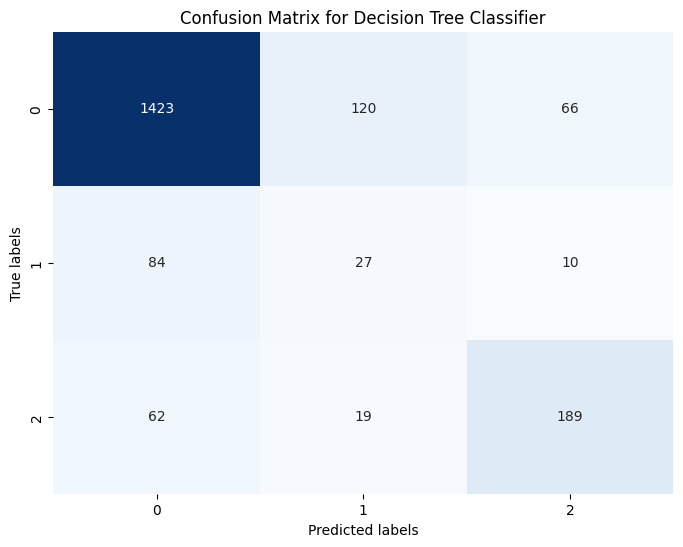

In [243]:
# Train Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
dt_pred = dt_classifier.predict(X_test)

dt_pred = dt_classifier.predict(X_test)


# Print classification report
print("Decision Tree Classifier:")
print(classification_report(y_test, dt_pred))

# Generate confusion matrix
cm = confusion_matrix(y_test, dt_pred)

# Plotting the confusion matrix using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

Naïve Bayes Classifier:
                       precision    recall  f1-score   support

    Highly Successful       0.99      0.30      0.46      1609
Moderately SUccessful       0.06      0.38      0.11       121
       Not Successful       0.32      0.98      0.49       270

             accuracy                           0.39      2000
            macro avg       0.46      0.55      0.35      2000
         weighted avg       0.85      0.39      0.44      2000



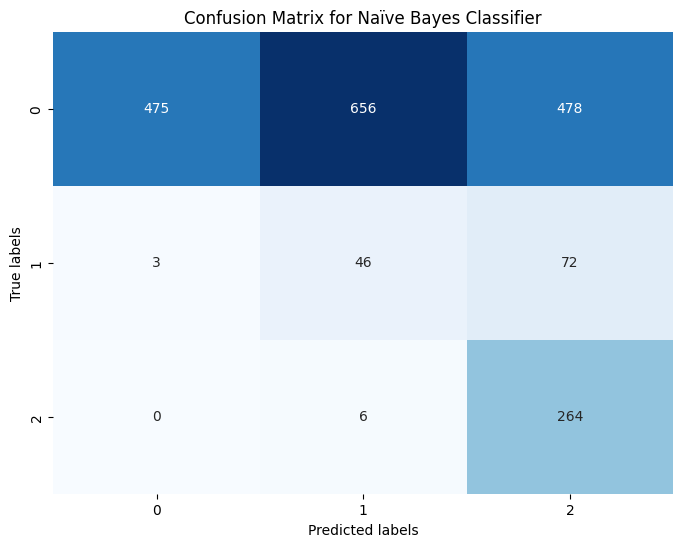

In [244]:
# Train Naïve Bayes Classifier
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
nb_pred = nb_classifier.predict(X_test)

print("Naïve Bayes Classifier:")
print(classification_report(y_test, nb_pred))

# Generate confusion matrix
cm = confusion_matrix(y_test, nb_pred)

# Plotting the confusion matrix using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix for Naïve Bayes Classifier')
plt.show()

K-Nearest Neighbor Classifier:
                       precision    recall  f1-score   support

    Highly Successful       0.82      0.96      0.89      1609
Moderately SUccessful       0.16      0.02      0.04       121
       Not Successful       0.39      0.14      0.20       270

             accuracy                           0.79      2000
            macro avg       0.46      0.37      0.38      2000
         weighted avg       0.72      0.79      0.74      2000



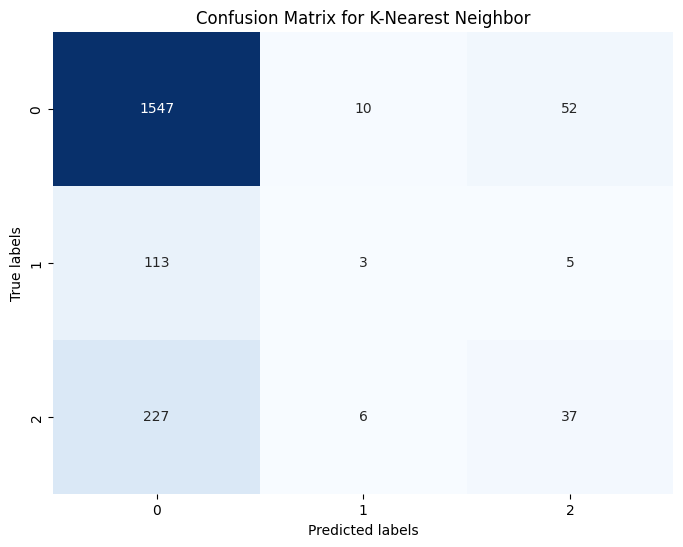

In [245]:
# Train K-Nearest Neighbor Classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train, y_train)
knn_pred = knn_classifier.predict(X_test)

print("K-Nearest Neighbor Classifier:")
print(classification_report(y_test, knn_pred))

# Generate confusion matrix
cm = confusion_matrix(y_test, knn_pred)

# Plotting the confusion matrix using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix for K-Nearest Neighbor')
plt.show()

Support Vector Machine Classifier:
                       precision    recall  f1-score   support

    Highly Successful       0.80      1.00      0.89      1609
Moderately SUccessful       0.00      0.00      0.00       121
       Not Successful       0.00      0.00      0.00       270

             accuracy                           0.80      2000
            macro avg       0.27      0.33      0.30      2000
         weighted avg       0.65      0.80      0.72      2000



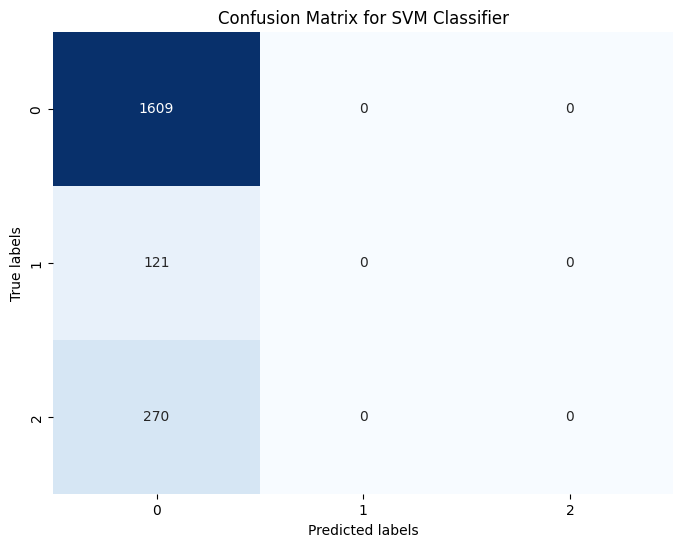

In [246]:
# Train Support Vector Machine Classifier
svm_classifier = SVC(kernel='rbf', random_state=42)
svm_classifier.fit(X_train, y_train)
svm_pred = svm_classifier.predict(X_test)

print("Support Vector Machine Classifier:")
print(classification_report(y_test, svm_pred))

# Generate confusion matrix
cm = confusion_matrix(y_test, svm_pred)

# Plotting the confusion matrix using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

Neural Network Classifier:
                       precision    recall  f1-score   support

    Highly Successful       0.81      0.98      0.89      1609
Moderately SUccessful       0.00      0.00      0.00       121
       Not Successful       0.38      0.09      0.14       270

             accuracy                           0.80      2000
            macro avg       0.40      0.35      0.34      2000
         weighted avg       0.70      0.80      0.73      2000



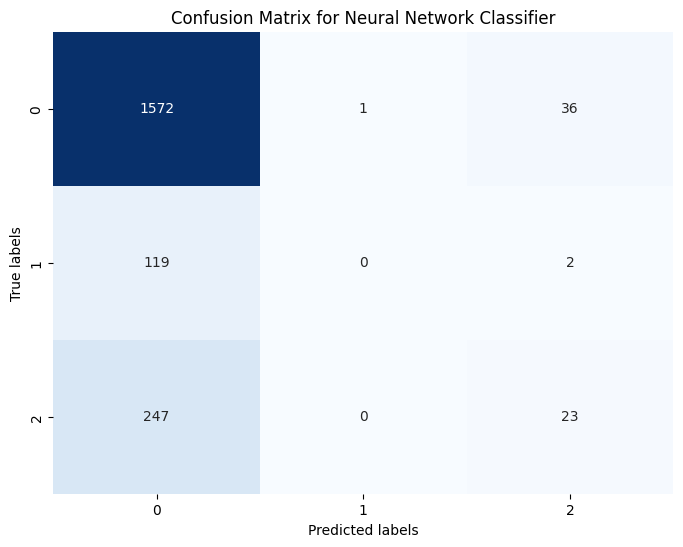

In [247]:
# Train Neural Network Classifier
nn_classifier = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)
nn_classifier.fit(X_train, y_train)
nn_pred = nn_classifier.predict(X_test)

print("Neural Network Classifier:")
print(classification_report(y_test, nn_pred))

# Generate confusion matrix
cm = confusion_matrix(y_test, nn_pred)

# Plotting the confusion matrix using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix for Neural Network Classifier')
plt.show()

# From the above set of Classifiers decision tree is a bit better at the work

Best Parameters: {'max_depth': 10, 'max_features': 'auto', 'min_samples_leaf': 2, 'min_samples_split': 10}
Best Score: 0.8685
Decision Tree Classifier:
                       precision    recall  f1-score   support

    Highly Successful       0.89      0.96      0.92      1609
Moderately SUccessful       0.11      0.02      0.03       121
       Not Successful       0.74      0.66      0.69       270

             accuracy                           0.86      2000
            macro avg       0.58      0.54      0.55      2000
         weighted avg       0.82      0.86      0.84      2000



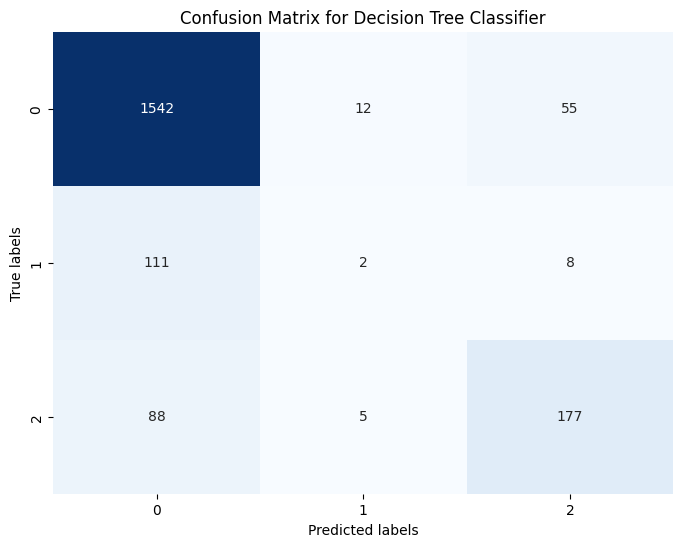

In [248]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Create the grid search object
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,
                           n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Train Decision Tree Classifier with best parameters
dt_classifier = DecisionTreeClassifier(**best_params, random_state=42)
dt_classifier.fit(X_train, y_train)
dt_pred = dt_classifier.predict(X_test)

# Evaluate the model
print("Best Parameters:", best_params)
print("Best Score:", best_score)
print("Decision Tree Classifier:")
print(classification_report(y_test, dt_pred))

# Generate confusion matrix
cm = confusion_matrix(y_test, dt_pred)

# Plotting the confusion matrix using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

# We have achived a toal of 86% auccracy in finding with app would be successful based of the given stats